# Data-to-Data Interpolation Experiments

## Motivation

The original Rectified Flow model learns a transformation from noise to data samples by approximating a continuous velocity field.

In this notebook, we investigate a different setting: **data-to-data interpolation**.

Instead of starting from random noise, we consider two samples from the data distribution:

- a source sample $x_A$
- a target sample $x_B$

and analyze how meaningful transitions between these samples can be constructed.

This experiment serves as a first baseline before applying the learned Rectified Flow dynamics to the interpolation task.

## Objective

The first experiment uses a simple linear interpolation between two samples:

$$
z_t = (1-t)x_A + tx_B
$$

where:

- $t=0$ corresponds to the source sample,
- $t=1$ corresponds to the target sample.

The goal is to investigate:

- whether the transition is visually meaningful,
- how the intermediate states behave,
- whether linear interpolation stays within the data manifold.

In [7]:
import sys
from pathlib import Path

import torch
import matplotlib.pyplot as plt

from torchvision import datasets, transforms


# Make repository root available
sys.path.append(str(Path("../").resolve()))


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize((0.5,), (0.5,))
])


dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform
)


print("Dataset size:", len(dataset))

Dataset size: 10000


In [8]:
# Choose two samples

idx_a = 0
idx_b = 1

x_a, label_a = dataset[idx_a]
x_b, label_b = dataset[idx_b]


print("Source label:", label_a)
print("Target label:", label_b)


# Add batch dimension
x_a = x_a.unsqueeze(0)
x_b = x_b.unsqueeze(0)

Source label: 7
Target label: 2


## Linear interpolation baseline

As a first baseline, we interpolate directly in pixel space.

This does not use the learned velocity field and only serves as a comparison point.

In [9]:
def linear_interpolation(x_a, x_b, steps=10):
    """
    Creates intermediate states:
    
    z_t = (1-t)x_A + tx_B
    """
    
    trajectory = []

    for t in torch.linspace(0, 1, steps):
        z_t = (1 - t) * x_a + t * x_b
        trajectory.append(z_t)

    return trajectory

In [10]:
linear_trajectory = linear_interpolation(
    x_a,
    x_b,
    steps=10
)


print(
    "Number of interpolation steps:",
    len(linear_trajectory)
)

Number of interpolation steps: 10


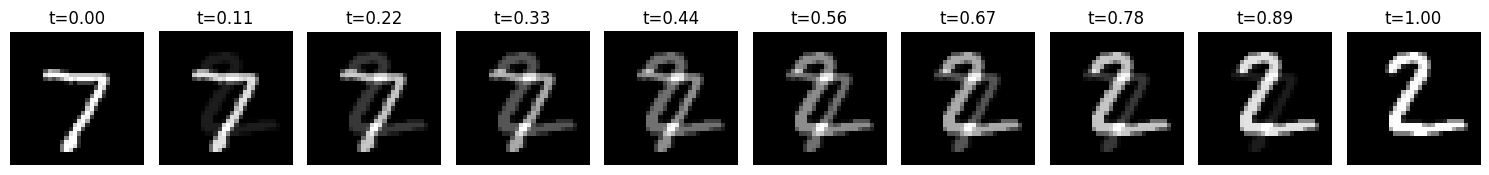

In [11]:
fig, axes = plt.subplots(
    1,
    len(linear_trajectory),
    figsize=(15,3)
)


for i, (ax, img) in enumerate(zip(axes, linear_trajectory)):

    img = img.squeeze()

    img = img * 0.5 + 0.5
    img = img.clamp(0,1)

    ax.imshow(img.cpu(), cmap="gray")
    ax.set_title(
        f"t={i/(len(linear_trajectory)-1):.2f}"
    )
    ax.axis("off")


plt.tight_layout()
plt.show()

## Observations

The linear interpolation provides a simple baseline for comparing different interpolation strategies.

Questions to analyze:

- Are intermediate states visually meaningful?
- Does the transition preserve semantic information?
- Do intermediate samples resemble valid digits?
- Does the interpolation move through unrealistic pixel configurations?

These observations serve as a reference when evaluating flow-based interpolation methods.

| Experiment | Source | Target | Method | Observation |
|------------|--------|--------|--------|-------------|
| Linear interpolation | digit ? | digit ? | Pixel interpolation | baseline |
| RF interpolation | digit ? | digit ? | Learned velocity field | TBD |